In [1]:
"""
Error Analysis with Interpretability

Since the final model (Logistic Regression) is interpretable, it can be explained directly
via its coefficients. No surrogate model (LIME/SHAP) is needed.
"""
import html
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Loading already pretrained model with preprocessed and split dataset
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")
model = joblib.load("../models/model.joblib")

In [2]:
# Recover the original message text for the test set
df = pd.read_csv("../data/raw/SMSSpamCollection.csv", sep="\t", header=None, names=["label", "message"])
# Convert HTML entities (e.g., '&lt;' to '<', '&gt;' to '>', '&amp;' to '&') back to standard text in all messages
df["message"] = df["message"].apply(html.unescape)
# Deleting the duplicates
df = df.drop_duplicates(subset=["message", "label"]).reset_index(drop=True)
# Applying "label" column to boolean, where 0 is ham and 1 is spam
y_full = df["label"].map({"ham": 0, "spam": 1})
_, X_test_raw, _, _ = train_test_split(df, y_full, train_size=0.80, random_state=42, stratify=y_full)
messages = X_test_raw["message"].reset_index(drop=True)

In [3]:
# Confusion matrix per risk level
levels = [([.0, .1], "Inbox"), ([.1, .4], "Review folder (likely a real customer)"), ([.4, .75], "Review folder (likely a real customer)"), ([.75, .95], "Likely spam"), ([.95, 1], "Spam")]

# raw probabilities
probs = model.predict_proba(X_test)[:, 1]
predictions_by_level = {}  # keeps every level's prediction array for later use

for t, label in levels:
    level_predictions = 1 - (probs <= t[1]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, level_predictions).ravel()
    print(f"\n{label} (t>={t[0]:.2f} and t<{t[1]:.2f}):")
    print(f"  True Negative (ham correctly shown):   {tn}")
    print(f"  False Positive (ham wrongly flagged):  {fp}")
    print(f"  False Negative (spam wrongly shown):   {fn}")
    print(f"  True Positive (spam correctly caught): {tp}")
    predictions_by_level[f"{label}"] = level_predictions


Inbox (t>=0.00 and t<0.10):
  True Negative (ham correctly shown):   889
  False Positive (ham wrongly flagged):  14
  False Negative (spam wrongly shown):   8
  True Positive (spam correctly caught): 123

Review folder (likely a real customer) (t>=0.10 and t<0.40):
  True Negative (ham correctly shown):   901
  False Positive (ham wrongly flagged):  2
  False Negative (spam wrongly shown):   8
  True Positive (spam correctly caught): 123

Review folder (likely a real customer) (t>=0.40 and t<0.75):
  True Negative (ham correctly shown):   902
  False Positive (ham wrongly flagged):  1
  False Negative (spam wrongly shown):   17
  True Positive (spam correctly caught): 114

Likely spam (t>=0.75 and t<0.95):
  True Negative (ham correctly shown):   903
  False Positive (ham wrongly flagged):  0
  False Negative (spam wrongly shown):   26
  True Positive (spam correctly caught): 105

Spam (t>=0.95 and t<1.00):
  True Negative (ham correctly shown):   903
  False Positive (ham wrongly fl

In [4]:
predictions_by_level

{'Inbox': array([0, 0, 0, ..., 1, 0, 0], shape=(1034,)),
 'Review folder (likely a real customer)': array([0, 0, 0, ..., 1, 0, 0], shape=(1034,)),
 'Likely spam': array([0, 0, 0, ..., 1, 0, 0], shape=(1034,)),
 'Spam': array([0, 0, 0, ..., 0, 0, 0], shape=(1034,))}

In [5]:
# Concrete misclassified examples
for predictions, label in levels:
    print(f"\nFolder: {label}\nFalse Positives: legitimate messages wrongly flagged as spam:")
    fp_idx = np.where((y_test.values == 0) & (predictions_by_level[label] == 1))[0]
    for i in fp_idx[:5]:
        print(f" - {messages.iloc[i][:100]}")
    print("\nFalse Negatives: spam that slipped through:")
    fn_idx = np.where((y_test.values == 1) & (predictions_by_level[label] == 0))[0]
    for i in fn_idx[:5]:
        print(f"  - {messages.iloc[i][:100]}")


Folder: Inbox
False Positives: legitimate messages wrongly flagged as spam:
 - K, wen ur free come to my home and also tel vikky i hav sent mail to him also.. Better come evening 
 - 7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS 
 - Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/
 - Aight I've been set free, think you could text me blake's address? It occurs to me I'm not quite as 
 - K k:) sms chat with me.

False Negatives: spam that slipped through:
  - You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Tele
  - Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy b
  - Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo
  - In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Gree
  - Latest News! Police station toilet stolen,

In [6]:
# Coefficient interpretation
coefs = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
print("\nTop 10 features indicating Ham (no spam) (most negative coefficients):")
print(coefs.head(10).round(2))
print("\nTop 10 features indicating Spam (most positive coefficients):")
print(coefs.tail(10).round(2))


Top 10 features indicating Ham (no spam) (most negative coefficients):
receive    -2.29
16         -1.74
holiday    -0.82
10         -0.59
msg        -0.33
wk         -0.26
contact    -0.26
2nd        -0.25
camera     -0.17
word_len   -0.17
dtype: float64

Top 10 features indicating Spam (most positive coefficients):
won         2.51
win         2.53
sms         2.58
http        2.94
uk          3.40
freemsg     3.42
content     3.49
service     3.56
rate        3.97
ringtone    4.95
dtype: float64


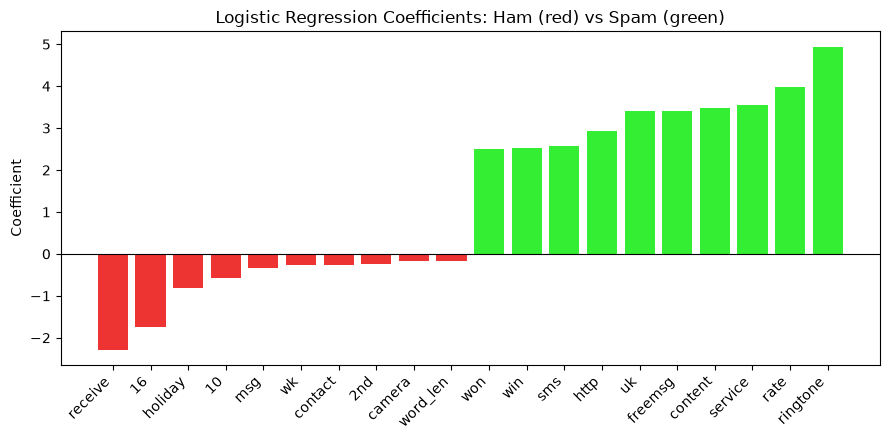

In [7]:
# Logistic Regression Coefficients figure creation
top20 = pd.concat([coefs.head(10), coefs.tail(10)])
colors = ["#EE3333" if v < 0 else "#33EE33" for v in top20.values]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(top20.index, top20.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients: Ham (red) vs Spam (green)")
ax.set_ylabel("Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/coefficients.png", dpi=150)
plt.show()
plt.close()
